# Plot das simulações do sistema aberto — 2x2

Este notebook carrega os resultados gerados por `run_lista_simulacoes_open_system.py` e monta figuras no mesmo formato do notebook antigo `plot_article_all_cases_2x2.ipynb`.

Para cada caso, a figura contém quatro painéis:

1. **não-classicalidade**;
2. **acoplamento** $g(t)$;
3. **valor esperado** $\langle Z \rangle$;
4. **valor esperado** $\langle N \rangle$.

Por padrão, o notebook não plota todas as 100, 200 ou 250 curvas. Ele usa apenas os índices representativos pedidos no PDF:

- $\zeta_{av}$;
- $T_{av}$;
- $\omega_{min}$;
- $\omega_{av}$.

Nos casos `specific_parameters`, ele plota todos os valores simulados, pois esses casos já foram definidos diretamente nos parâmetros pedidos.

In [1]:
import os
import glob
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (12, 8),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})

## Configuração

Se quiser escolher uma rodada específica, coloque o caminho manualmente em `ROOT`.

Se deixar `ROOT = None`, o notebook pega automaticamente a pasta mais recente em:

```text
results/lista_simulacoes_open_system/open_system_sims*
```

A chave `SELECTED_ONLY = True` reproduz o que o PDF pede para a visualização no notebook. Para tentar plotar todas as curvas de uma varredura, mude para `False`.

In [2]:
BASE = "results/lista_simulacoes_open_system"
ROOT = None

# True: plota apenas os índices pedidos no PDF.
# False: tenta plotar todos os parâmetros de cada varredura.
SELECTED_ONLY = True

# Salvamento das figuras.
SAVE_FIGURES = True
SAVE_PNG = True
SAVE_PDF = True
DPI = 220

# Diretório de saída das figuras.
FIG_DIR_NAME = "figures_2x2"

## Localizar a pasta de resultados

In [3]:
def latest_root(base=BASE):
    folders = sorted(glob.glob(os.path.join(base, "open_system_sims*")))
    if not folders:
        raise FileNotFoundError(
            "Não encontrei resultados. Rode primeiro: python run_lista_simulacoes_open_system.py"
        )
    return folders[-1]

if ROOT is None:
    ROOT = latest_root()

ROOT

'results/lista_simulacoes_open_system/open_system_sims1'

## Tabela de casos disponíveis

In [4]:
case_map_path = os.path.join(ROOT, "case_map.csv")
if not os.path.exists(case_map_path):
    raise FileNotFoundError(f"Não achei: {case_map_path}")

case_map = pd.read_csv(case_map_path)
case_map

,case_id,block,resource,state_kind,coupling,scan_name,scan_display_name,n_scan,tmax,metric_label,fixed_args,note
0,only_dephasing_wigner_gauss_zeta,only_dephasing,wigner,wigner,gauss,epsilon,zeta,250,15.0,N_W(t),"{""T"": 7.5, ""sigma"": -1.0}",Wigner: gaussian varying width; plotting av in...
1,only_dephasing_wigner_gauss_T,only_dephasing,wigner,wigner,gauss,T,T,100,15.0,N_W(t),"{""epsilon"": 2.4, ""sigma"": -1.0}",Wigner: gaussian varying peak time; plotting a...
2,only_dephasing_wigner_cos_omega,only_dephasing,wigner,wigner,cos,w,omega,100,15.0,N_W(t),"{""phi"": 0.0}",Wigner: cosine varying frequency; plotting min...
3,only_dephasing_coherence_gauss_zeta,only_dephasing,coherence,coherence,gauss,epsilon,zeta,100,50.0,C_q(t),"{""T"": 25.0, ""sigma"": -1.0}",coherence: gaussian varying width; plotting av...
4,only_dephasing_coherence_gauss_T,only_dephasing,coherence,coherence,gauss,T,T,100,50.0,C_q(t),"{""epsilon"": 8.0, ""sigma"": -1.0}",coherence: gaussian varying peak time; plottin...
5,only_dephasing_coherence_cos_omega,only_dephasing,coherence,coherence,cos,w,omega,200,50.0,C_q(t),"{""phi"": 0.0}",coherence: cosine varying frequency; plotting ...
6,only_dephasing_magic_gauss_zeta,only_dephasing,magic,magic,gauss,epsilon,zeta,100,50.0,M_2(t),"{""T"": 25.0, ""sigma"": -1.0}",magic: gaussian varying width; plotting av ind...
7,only_dephasing_magic_gauss_T,only_dephasing,magic,magic,gauss,T,T,100,50.0,M_2(t),"{""epsilon"": 8.0, ""sigma"": -1.0}",magic: gaussian varying peak time; plotting av...
8,only_dephasing_magic_cos_omega,only_dephasing,magic,magic,cos,w,omega,200,50.0,M_2(t),"{""phi"": 0.0}",magic: cosine varying frequency; plotting min ...
9,only_dephasing_entanglement_gauss_zeta,only_dephasing,entanglement,entanglement,gauss,epsilon,zeta,100,50.0,E_N(t),"{""T"": 25.0, ""sigma"": -1.0}",entanglement: gaussian varying width; plotting...


## Funções de leitura

In [5]:
def case_dir(case_id):
    return os.path.join(ROOT, case_id)


def read_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def load_case(case_id):
    folder = case_dir(case_id)

    meta_path = os.path.join(folder, "case_metadata.json")
    t_path = os.path.join(folder, "t.npy")
    args_path = os.path.join(folder, "args_per_scan.csv")
    summary_path = os.path.join(folder, "summary.csv")

    if not os.path.exists(meta_path):
        raise FileNotFoundError(f"Não achei: {meta_path}")
    if not os.path.exists(t_path):
        raise FileNotFoundError(f"Não achei: {t_path}")
    if not os.path.exists(args_path):
        raise FileNotFoundError(f"Não achei: {args_path}")

    data = {
        "folder": folder,
        "meta": read_json(meta_path),
        "t": np.load(t_path),
        "args": pd.read_csv(args_path),
    }

    if os.path.exists(summary_path):
        data["summary"] = pd.read_csv(summary_path)
    else:
        data["summary"] = None

    return data


def load_metric(folder, label):
    path = os.path.join(folder, f"{label}.npy")
    if not os.path.exists(path):
        raise FileNotFoundError(f"Não achei: {path}")
    return np.load(path)


def load_observables(folder, label):
    path = os.path.join(folder, f"{label}_observables.csv")
    if not os.path.exists(path):
        raise FileNotFoundError(f"Não achei: {path}")
    return pd.read_csv(path)

## Seleção dos índices pedidos no PDF

O PDF usa uma notação do tipo `125+1th parameter`. Como Python conta do zero, isso vira índice `125`.

Exemplos:

- `125+1th` $\rightarrow$ índice Python `125`;
- `50+1th` $\rightarrow$ índice Python `50`;
- `100+1th` $\rightarrow$ índice Python `100`.

In [6]:
def clip_indices(indices, n):
    out = []
    for idx in indices:
        idx = int(idx)
        if idx < 0:
            continue
        if idx >= n:
            idx = n - 1
        if idx not in out:
            out.append(idx)
    return out


def selected_scan_indices(meta, args_df):
    n = len(args_df)
    if n == 0:
        return []

    block = str(meta.get("block", ""))
    resource = str(meta.get("resource", ""))
    coupling = str(meta.get("coupling", ""))
    scan_name = str(meta.get("scan_name", ""))

    # Nos casos specific_parameters, o script de simulação já rodou exatamente
    # os parâmetros pedidos no PDF. Então o correto é plotar todos.
    if block == "specific_parameters":
        return list(range(n))

    # Wigner: t em [0, 15]
    if resource == "wigner":
        if coupling == "gauss" and scan_name == "epsilon":
            return clip_indices([125], n)       # zeta_av
        if coupling == "gauss" and scan_name == "T":
            return clip_indices([50], n)        # T_av
        if coupling == "cos" or scan_name == "w":
            return clip_indices([25, 50], n)    # omega_min, omega_av

    # Coherence, Magic, Entanglement: t em [0, 50]
    if resource in {"coherence", "magic", "entanglement"}:
        if coupling == "gauss" and scan_name == "epsilon":
            return clip_indices([50], n)        # zeta_av
        if coupling == "gauss" and scan_name == "T":
            return clip_indices([50], n)        # T_av
        if coupling == "cos" or scan_name == "w":
            return clip_indices([50, 100], n)   # omega_min, omega_av

    # Fallback simples, caso apareça algum caso não previsto.
    return clip_indices([n // 2], n)

## Funções de formatação

In [7]:
def safe_log_limits(arrays, floor=1e-12):
    vals = []
    for arr in arrays:
        arr = np.asarray(arr, dtype=float)
        vals.extend(arr[np.isfinite(arr) & (arr > 0)].tolist())
    if not vals:
        return floor, 1.0
    return max(floor, min(vals) * 0.7), max(vals) * 1.3


def use_log_for_metric(resource):
    return resource in {"coherence", "entanglement"}


def metric_name(meta):
    label = meta.get("metric_label")
    if isinstance(label, str) and label.strip():
        return label

    resource = meta.get("resource", "")
    if resource == "wigner":
        return r"$N_W(t)$"
    if resource == "coherence":
        return r"$C_q(t)$"
    if resource == "magic":
        return r"$M_2(t)$"
    if resource == "entanglement":
        return r"$E_N(t)$"
    return "non-classicality"


def format_pi_value(x, tol=1e-8):
    if not np.isfinite(x):
        return "nan"

    candidates = [
        (1 / 20, r"\pi/20"),
        (1 / 10, r"\pi/10"),
        (1 / 6, r"\pi/6"),
        (1 / 5, r"\pi/5"),
        (1 / 3, r"\pi/3"),
        (2 / 3, r"2\pi/3"),
    ]
    for frac, text in candidates:
        if abs(x - frac * np.pi) < tol:
            return f"${text}$"
    return f"{x:.4g}"


def pretty_scan_label(row):
    name = str(row.get("scan_display_name", row.get("scan_name", "param")))
    value = float(row.get("scan_value", np.nan))
    idx = int(row.get("scan_index_python", -1))

    if "omega" in name or str(row.get("scan_name", "")) == "w":
        val = format_pi_value(value)
    else:
        val = f"{value:.4g}"

    return f"{name} = {val}  [i={idx}]"


def get_z_column(df):
    for col in ["expect_Z_qubit", "expect_Z", "expect_Z_global"]:
        if col in df.columns:
            return col
    raise KeyError(
        "Não achei coluna de Z. Esperava uma destas: "
        "expect_Z_qubit, expect_Z, expect_Z_global"
    )


def safe_filename(name):
    keep = []
    for ch in str(name):
        if ch.isalnum() or ch in "._-":
            keep.append(ch)
        else:
            keep.append("_")
    out = "".join(keep)
    while "__" in out:
        out = out.replace("__", "_")
    return out.strip("_")

## Escolher quais curvas entram em cada figura

In [8]:
def rows_to_plot(data, selected_only=SELECTED_ONLY):
    args_df = data["args"].copy()

    if selected_only:
        indices = selected_scan_indices(data["meta"], args_df)
    else:
        indices = list(range(len(args_df)))

    rows = []

    # Curva de referência com acoplamento constante, se existir.
    const_path = os.path.join(data["folder"], "const_aberto.npy")
    const_obs = os.path.join(data["folder"], "const_aberto_observables.csv")
    if os.path.exists(const_path) and os.path.exists(const_obs):
        rows.append({
            "label": "const_aberto",
            "pretty": "constant open",
            "kind": "constant",
            "scan_index_python": -1,
            "scan_index_text_1_based": 0,
            "scan_value": np.nan,
        })

    for idx in indices:
        if idx < 0 or idx >= len(args_df):
            continue

        row = args_df.iloc[int(idx)]
        label = str(row["label"])

        rows.append({
            "label": label,
            "pretty": pretty_scan_label(row),
            "kind": "variable",
            "scan_index_python": int(row.get("scan_index_python", idx)),
            "scan_index_text_1_based": int(row.get("scan_index_text_1_based", idx + 1)),
            "scan_value": float(row.get("scan_value", np.nan)),
        })

    return rows


def selected_curves_table(case_id):
    data = load_case(case_id)
    rows = rows_to_plot(data)
    return pd.DataFrame(rows)

## Função principal de plotagem 2x2

In [9]:
def plot_case_2x2(case_id, save=SAVE_FIGURES, show=True):
    data = load_case(case_id)
    meta = data["meta"]
    t = data["t"]
    folder = data["folder"]
    resource = meta.get("resource", "")

    rows = rows_to_plot(data)
    if not rows:
        print(f"[skip] {case_id}: nenhuma curva encontrada")
        return None

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(12.0, 8.0),
        sharex="col",
        constrained_layout=True,
    )

    ax_metric = axes[0, 0]
    ax_g = axes[0, 1]
    ax_z = axes[1, 0]
    ax_n = axes[1, 1]

    metric_arrays = []
    legend_handles = []
    legend_labels = []
    plotted_rows = []

    for row in rows:
        label = row["label"]
        pretty = row["pretty"]

        try:
            y_metric = load_metric(folder, label)
            obs = load_observables(folder, label)
        except FileNotFoundError as exc:
            print(f"[missing] {case_id} | {label}: {exc}")
            continue

        tt = obs["time"].to_numpy(dtype=float) if "time" in obs.columns else t
        z_col = get_z_column(obs)

        if row["kind"] == "constant":
            style = {"lw": 2.2, "linestyle": "--"}
        else:
            style = {"lw": 1.9}

        line_metric, = ax_metric.plot(t, y_metric, label=pretty, **style)
        ax_g.plot(tt, obs["g_t"].to_numpy(dtype=float), **style)
        ax_z.plot(tt, obs[z_col].to_numpy(dtype=float), **style)
        ax_n.plot(tt, obs["expect_N"].to_numpy(dtype=float), **style)

        metric_arrays.append(y_metric)
        legend_handles.append(line_metric)
        legend_labels.append(pretty)
        plotted_rows.append(row)

    if not plotted_rows:
        plt.close(fig)
        print(f"[skip] {case_id}: arquivos ainda incompletos")
        return None

    if use_log_for_metric(resource):
        ax_metric.set_yscale("log")
        ax_metric.set_ylim(*safe_log_limits(metric_arrays))

    ax_metric.set_ylabel(metric_name(meta))
    ax_metric.set_title("Non-classicality")

    ax_g.set_ylabel(r"$g(t)$")
    ax_g.set_title("Coupling")

    ax_z.set_ylabel(r"$\langle Z \rangle$")
    ax_z.set_title(r"Expected value of $Z$")
    ax_z.set_xlabel("t")

    ax_n.set_ylabel(r"$\langle N \rangle$")
    ax_n.set_title(r"Expected value of $N$")
    ax_n.set_xlabel("t")

    title = (
        f"{meta.get('block', '')} | {meta.get('resource', '')} | "
        f"{meta.get('coupling', '')} | {meta.get('scan_display_name', '')}"
    )
    fig.suptitle(title, fontsize=13)
    fig.legend(legend_handles, legend_labels, loc="upper center", ncol=4, fontsize=9)

    out_paths = []
    if save:
        fig_dir = os.path.join(ROOT, FIG_DIR_NAME)
        os.makedirs(fig_dir, exist_ok=True)
        base = os.path.join(fig_dir, f"plot_2x2_{safe_filename(case_id)}")

        if SAVE_PNG:
            png = base + ".png"
            fig.savefig(png, dpi=DPI, bbox_inches="tight")
            out_paths.append(png)

        if SAVE_PDF:
            pdf = base + ".pdf"
            fig.savefig(pdf, bbox_inches="tight")
            out_paths.append(pdf)

    if show:
        plt.show()
    else:
        plt.close(fig)

    return {
        "case_id": case_id,
        "n_curves": len(plotted_rows),
        "files": ";".join(out_paths),
    }

## Conferir um caso específico

In [10]:
# Escolha um caso da tabela case_map.
case_id = case_map.iloc[0]["case_id"]
case_id

'only_dephasing_wigner_gauss_zeta'

### Curvas que serão usadas neste caso

In [11]:
selected_curves_table(case_id)

,label,pretty,kind,scan_index_python,scan_index_text_1_based,scan_value
0,const_aberto,constant open,constant,-1,0,NaN
1,var_aberto_0125_zeta_2p40240963855,zeta = 2.402 [i=125],variable,125,126,2.40241


### Figura 2x2

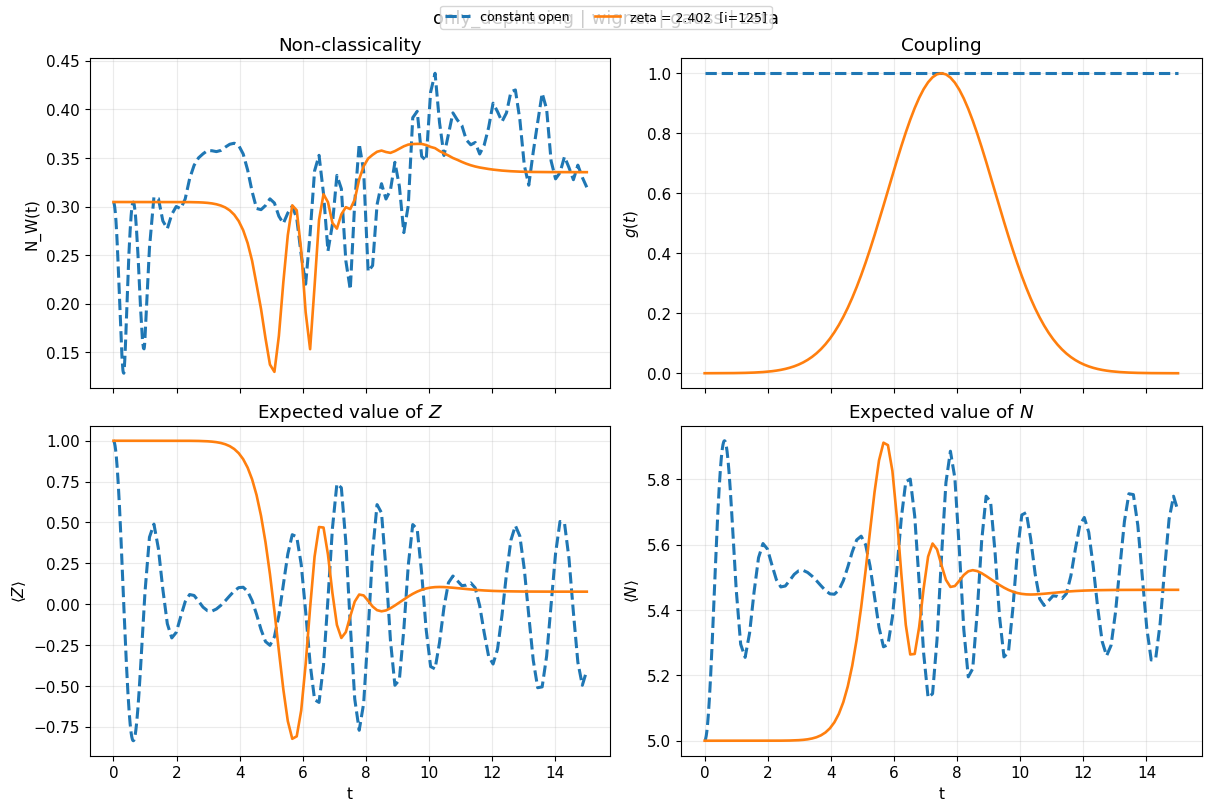

{'case_id': 'only_dephasing_wigner_gauss_zeta', 'n_curves': 2, 'files': ''}

In [12]:
plot_case_2x2(case_id, save=False, show=True)

## Resumo numérico do caso

In [13]:
data = load_case(case_id)
data["summary"]

,case_id,label,block,resource,coupling,scan_name,scan_index_python,scan_value,metric_initial,metric_max,metric_mean,metric_final,time_at_max,scan_display_name,scan_index_text_1_based
0,only_dephasing_wigner_gauss_zeta,const_aberto,only_dephasing,wigner,gauss,const,-1,NaN,0.304704,0.437083,0.280101,0.319861,10.191919,NaN,NaN
1,only_dephasing_wigner_gauss_zeta,var_aberto_0000_zeta_1p8,only_dephasing,wigner,gauss,epsilon,0,1.800000,0.304704,0.357558,0.310035,0.355902,9.767677,zeta,1.0
2,only_dephasing_wigner_gauss_zeta,var_aberto_0001_zeta_1p80481927711,only_dephasing,wigner,gauss,epsilon,1,1.804819,0.304704,0.357385,0.310005,0.355766,9.626263,zeta,2.0
3,only_dephasing_wigner_gauss_zeta,var_aberto_0002_zeta_1p80963855422,only_dephasing,wigner,gauss,epsilon,2,1.809639,0.304704,0.357528,0.309984,0.355721,9.626263,zeta,3.0
4,only_dephasing_wigner_gauss_zeta,var_aberto_0003_zeta_1p81445783133,only_dephasing,wigner,gauss,epsilon,3,1.814458,0.304704,0.357682,0.309976,0.355711,9.626263,zeta,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246,only_dephasing_wigner_gauss_zeta,var_aberto_0245_zeta_2p98072289157,only_dephasing,wigner,gauss,epsilon,245,2.980723,0.304704,0.364061,0.296813,0.284078,8.777778,zeta,246.0
247,only_dephasing_wigner_gauss_zeta,var_aberto_0246_zeta_2p98554216867,only_dephasing,wigner,gauss,epsilon,246,2.985542,0.304704,0.364250,0.296674,0.283156,8.777778,zeta,247.0
248,only_dephasing_wigner_gauss_zeta,var_aberto_0247_zeta_2p99036144578,only_dephasing,wigner,gauss,epsilon,247,2.990361,0.304704,0.364400,0.296547,0.282662,8.777778,zeta,248.0
249,only_dephasing_wigner_gauss_zeta,var_aberto_0248_zeta_2p99518072289,only_dephasing,wigner,gauss,epsilon,248,2.995181,0.304704,0.364447,0.296448,0.282655,8.777778,zeta,249.0


## Plotar e salvar todos os casos

Por padrão, esta célula salva as figuras em:

```text
ROOT/figures_2x2/
```

Se quiser apenas visualizar sem salvar, use `SAVE_ALL = False` e `SHOW_ALL = True`.

In [14]:
SAVE_ALL = True
SHOW_ALL = False

records = []

for cid in case_map["case_id"].tolist():
    try:
        rec = plot_case_2x2(cid, save=SAVE_ALL, show=SHOW_ALL)
        if rec is not None:
            records.append(rec)
            print(f"[ok] {cid}: {rec['n_curves']} curva(s)")
    except Exception as exc:
        print(f"[error] {cid}: {exc}")

fig_index = pd.DataFrame(records)

if SAVE_ALL and len(fig_index) > 0:
    fig_dir = os.path.join(ROOT, FIG_DIR_NAME)
    os.makedirs(fig_dir, exist_ok=True)
    out_csv = os.path.join(fig_dir, "figures_2x2_index.csv")
    fig_index.to_csv(out_csv, index=False)
    print("\nÍndice salvo em:", out_csv)

fig_index

[ok] only_dephasing_wigner_gauss_zeta: 2 curva(s)
[ok] only_dephasing_wigner_gauss_T: 2 curva(s)
[ok] only_dephasing_wigner_cos_omega: 3 curva(s)
[ok] only_dephasing_coherence_gauss_zeta: 2 curva(s)
[ok] only_dephasing_coherence_gauss_T: 2 curva(s)
[ok] only_dephasing_coherence_cos_omega: 3 curva(s)
[ok] only_dephasing_magic_gauss_zeta: 2 curva(s)
[ok] only_dephasing_magic_gauss_T: 2 curva(s)
[ok] only_dephasing_magic_cos_omega: 3 curva(s)
[ok] only_dephasing_entanglement_gauss_zeta: 2 curva(s)
[ok] only_dephasing_entanglement_gauss_T: 2 curva(s)
[ok] only_dephasing_entanglement_cos_omega: 3 curva(s)
[ok] only_cavity_damping_wigner_gauss_zeta: 2 curva(s)
[ok] only_cavity_damping_wigner_gauss_T: 2 curva(s)
[ok] only_cavity_damping_wigner_cos_omega: 3 curva(s)
[ok] only_cavity_damping_coherence_gauss_zeta: 2 curva(s)
[ok] only_cavity_damping_coherence_gauss_T: 2 curva(s)
[ok] only_cavity_damping_coherence_cos_omega: 3 curva(s)
[ok] only_cavity_damping_magic_gauss_zeta: 2 curva(s)
[ok] on

,case_id,n_curves,files
0,only_dephasing_wigner_gauss_zeta,2,results/lista_simulacoes_open_system/open_syst...
1,only_dephasing_wigner_gauss_T,2,results/lista_simulacoes_open_system/open_syst...
2,only_dephasing_wigner_cos_omega,3,results/lista_simulacoes_open_system/open_syst...
3,only_dephasing_coherence_gauss_zeta,2,results/lista_simulacoes_open_system/open_syst...
4,only_dephasing_coherence_gauss_T,2,results/lista_simulacoes_open_system/open_syst...
5,only_dephasing_coherence_cos_omega,3,results/lista_simulacoes_open_system/open_syst...
6,only_dephasing_magic_gauss_zeta,2,results/lista_simulacoes_open_system/open_syst...
7,only_dephasing_magic_gauss_T,2,results/lista_simulacoes_open_system/open_syst...
8,only_dephasing_magic_cos_omega,3,results/lista_simulacoes_open_system/open_syst...
9,only_dephasing_entanglement_gauss_zeta,2,results/lista_simulacoes_open_system/open_syst...


## Diagnóstico rápido: casos incompletos

Use esta célula para verificar quais casos ainda não possuem todos os arquivos esperados para as curvas selecionadas.

In [15]:
missing_rows = []

for cid in case_map["case_id"].tolist():
    try:
        data = load_case(cid)
        rows = rows_to_plot(data)
        for row in rows:
            label = row["label"]
            metric_path = os.path.join(data["folder"], f"{label}.npy")
            obs_path = os.path.join(data["folder"], f"{label}_observables.csv")
            if not os.path.exists(metric_path) or not os.path.exists(obs_path):
                missing_rows.append({
                    "case_id": cid,
                    "label": label,
                    "missing_metric": not os.path.exists(metric_path),
                    "missing_observables": not os.path.exists(obs_path),
                })
    except Exception as exc:
        missing_rows.append({
            "case_id": cid,
            "label": "__case_load_error__",
            "missing_metric": True,
            "missing_observables": True,
            "error": repr(exc),
        })

pd.DataFrame(missing_rows)

""
